# 07 — Twitch Inference Benchmark

Final notebook in the 7-notebook sequence.

This notebook benchmarks the CPU serving behavior of:

- Logistic Regression
- HistGradientBoosting
- PyTorch MLP
- TorchScript MLP

for candidate batch sizes of **1, 10, 50, 100, and 200**.

Metrics:

- mean latency
- P50 latency
- P95 latency
- P99 latency
- rows/sec throughput
- Top-K sorting overhead
- score + Top-K request-path latency

This benchmark intentionally uses the already prepared **36-feature ranking rows**. Notebook 06 showed that arbitrary candidates from Notebook 05 still need the exact dynamic 36-feature builder before full end-to-end inference is valid.


In [1]:
from __future__ import annotations

import gc
import json
import os
from pathlib import Path
from time import perf_counter

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

SEED = 42
rng = np.random.default_rng(SEED)

torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
DEVICE = torch.device("cpu")

print("Torch:", torch.__version__)
print("Device:", DEVICE)
print("Torch threads:", torch.get_num_threads())


Torch: 2.14.0
Device: cpu
Torch threads: 4


## 1. Locate project and artifacts

In [2]:
HOME_PROJECT = Path.home() / "Desktop" / "resume_projects" / "Distributed ML Inference & Ranking"
cwd = Path.cwd()

PROJECT_CANDIDATES = [HOME_PROJECT, cwd, *cwd.parents]

PROJECT_DIR = next(
    (
        p for p in PROJECT_CANDIDATES
        if (
            (p / "data/processed/twitch/twitch_test_ranking.csv.gz").exists()
            or (p / "data/raw/twitch/100k_a.csv").exists()
        )
    ),
    None,
)

if PROJECT_DIR is None:
    raise FileNotFoundError("Could not locate project root. Set PROJECT_DIR manually.")

RESULTS_DIR = PROJECT_DIR / "results/07_twitch_inference_benchmark"
ARTIFACT_DIR = PROJECT_DIR / "artifacts/twitch"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

def find_file(filenames, required=True, prefer_terms=()):
    if isinstance(filenames, str):
        filenames = [filenames]

    matches = []
    for filename in filenames:
        matches.extend(PROJECT_DIR.rglob(filename))

    matches = list(dict.fromkeys(matches))

    if not matches:
        if required:
            raise FileNotFoundError("Could not find: " + ", ".join(filenames))
        return None

    def rank(path):
        text = str(path).lower()
        preference = sum(term.lower() in text for term in prefer_terms)
        return (-preference, len(path.parts), len(str(path)))

    return sorted(matches, key=rank)[0]

TEST_PATH = find_file(
    "twitch_test_ranking.csv.gz",
    prefer_terms=("data/processed/twitch",),
)

LOGREG_PATH = find_file(
    "baseline_logistic_regression.joblib",
    prefer_terms=("artifacts/twitch",),
)

HGB_PATH = find_file(
    "baseline_hist_gradient_boosting.joblib",
    prefer_terms=("artifacts/twitch",),
)

NEURAL_MODEL_PATH = find_file(
    "neural_ranker.pt",
    prefer_terms=("artifacts/twitch",),
)

NEURAL_PREPROCESS_PATH = find_file(
    "neural_ranker_preprocessing.joblib",
    prefer_terms=("artifacts/twitch",),
)

NEURAL_PRED_PATH = find_file(
    ["neural_predictions_mac_subset.csv.gz", "neural_predictions.csv.gz"],
    required=False,
    prefer_terms=("predictions",),
)

TORCHSCRIPT_PATH = find_file(
    [
        "neural_ranker_torchscript.pt",
        "neural_ranker_traced.pt",
        "twitch_neural_ranker_torchscript.pt",
    ],
    required=False,
    prefer_terms=("artifacts/twitch",),
)

print("Project:", PROJECT_DIR)
print("Test:", TEST_PATH)
print("Logistic:", LOGREG_PATH)
print("HGB:", HGB_PATH)
print("Neural:", NEURAL_MODEL_PATH)
print("Neural preprocessing:", NEURAL_PREPROCESS_PATH)
print("TorchScript:", TORCHSCRIPT_PATH)


Project: /Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking
Test: /Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/data/processed/twitch/twitch_test_ranking.csv.gz
Logistic: /Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/artifacts/twitch/baseline_logistic_regression.joblib
HGB: /Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/artifacts/twitch/baseline_hist_gradient_boosting.joblib
Neural: /Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/notebooks/Distributed ML Inference & Ranking/artifacts/twitch/neural_ranker.pt
Neural preprocessing: /Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/notebooks/Distributed ML Inference & Ranking/artifacts/twitch/neural_ranker_preprocessing.joblib
TorchScript: /Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/notebooks/Distributed ML Inference & Ranking/artifacts/twitch/neural_ranker_traced

## 2. Load models and feature contract

In [3]:
logreg = joblib.load(LOGREG_PATH)

hgb_bundle = joblib.load(HGB_PATH)
if not isinstance(hgb_bundle, dict):
    raise TypeError("Expected HGB artifact to be a dict.")

hgb = hgb_bundle["model"]
hgb_imputer = hgb_bundle["imputer"]
FEATURE_COLUMNS = list(hgb_bundle["feature_columns"])

neural_bundle = torch.load(
    NEURAL_MODEL_PATH,
    map_location="cpu",
    weights_only=False,
)

neural_preprocess = joblib.load(NEURAL_PREPROCESS_PATH)
neural_imputer = neural_preprocess["imputer"]
neural_scaler = neural_preprocess["scaler"]
NEURAL_FEATURE_COLUMNS = list(neural_preprocess["feature_columns"])

print("HGB feature count:", len(FEATURE_COLUMNS))
print("Neural feature count:", len(NEURAL_FEATURE_COLUMNS))

if FEATURE_COLUMNS != NEURAL_FEATURE_COLUMNS:
    raise ValueError("HGB and neural models use different feature order.")

print("Feature contract matches.")


HGB feature count: 36
Neural feature count: 36
Feature contract matches.


## 3. Rebuild PyTorch MLP and create/load TorchScript

In [4]:
class TwitchMLPRanker(nn.Module):
    def __init__(self, input_dim, hidden_dims=(48, 24)):
        super().__init__()
        h1, h2 = hidden_dims
        self.network = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)

architecture = tuple(neural_bundle.get("architecture", [48, 24]))

neural_model = TwitchMLPRanker(
    input_dim=len(FEATURE_COLUMNS),
    hidden_dims=architecture,
)

neural_model.load_state_dict(neural_bundle["state_dict"])
neural_model.eval().to(DEVICE)

if TORCHSCRIPT_PATH is not None:
    scripted_model = torch.jit.load(str(TORCHSCRIPT_PATH), map_location="cpu")
    scripted_model.eval()
    print("Loaded TorchScript:", TORCHSCRIPT_PATH)
else:
    example_input = torch.zeros(
        1,
        len(FEATURE_COLUMNS),
        dtype=torch.float32,
    )

    scripted_model = torch.jit.trace(neural_model, example_input)
    scripted_model.eval()

    TORCHSCRIPT_PATH = ARTIFACT_DIR / "neural_ranker_torchscript.pt"
    scripted_model.save(str(TORCHSCRIPT_PATH))

    print("Created TorchScript:", TORCHSCRIPT_PATH)


Loaded TorchScript: /Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/notebooks/Distributed ML Inference & Ranking/artifacts/twitch/neural_ranker_traced.pt


/opt/anaconda3/envs/distributed-ml/lib/python3.11/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


## 4. Load fair benchmark population

In [5]:
test = pd.read_csv(TEST_PATH)

missing_features = [c for c in FEATURE_COLUMNS if c not in test.columns]
if missing_features:
    raise ValueError(f"Prepared test table is missing: {missing_features}")

if NEURAL_PRED_PATH is not None:
    neural_keys = (
        pd.read_csv(
            NEURAL_PRED_PATH,
            usecols=["user_id", "streamer"],
        )
        .drop_duplicates(["user_id", "streamer"])
    )

    bench = test.merge(
        neural_keys,
        on=["user_id", "streamer"],
        how="inner",
    )

    print("Using Notebook 04 comparison population.")
else:
    sample_n = min(120_000, len(test))
    bench = test.sample(n=sample_n, random_state=SEED)
    print("Using reproducible prepared-test sample.")

bench = bench.reset_index(drop=True)

print("Benchmark rows:", f"{len(bench):,}")
print("Benchmark users:", f"{bench['user_id'].nunique():,}")
print("Features:", len(FEATURE_COLUMNS))


Using Notebook 04 comparison population.
Benchmark rows: 118,750
Benchmark users: 5,000
Features: 36


## 5. Prepare model-specific arrays

In [6]:
X_raw = bench[FEATURE_COLUMNS].copy()

X_hgb = hgb_imputer.transform(X_raw).astype(np.float32, copy=False)

X_neural = neural_imputer.transform(X_raw)
X_neural = neural_scaler.transform(X_neural).astype(np.float32, copy=False)

print("X_hgb:", X_hgb.shape, X_hgb.dtype)
print("X_neural:", X_neural.shape, X_neural.dtype)
print(
    "Approx array memory:",
    f"{(X_hgb.nbytes + X_neural.nbytes) / 1024**2:.1f} MB",
)


X_hgb: (118750, 36) float32
X_neural: (118750, 36) float32
Approx array memory: 32.6 MB


# Benchmark A — model-only inference

This isolates scoring performance. HGB and neural models use preprocessed arrays. Logistic Regression uses its fitted sklearn pipeline.


In [7]:
BATCH_SIZES = [1, 10, 50, 100, 200]

REPEATS_BY_BATCH = {
    1: 300,
    10: 250,
    50: 200,
    100: 150,
    200: 120,
}

WARMUP_RUNS = 20

print("Batch sizes:", BATCH_SIZES)


Batch sizes: [1, 10, 50, 100, 200]


## 6. Benchmark helpers

In [8]:
def sample_indices(batch_size):
    return rng.integers(0, len(bench), size=batch_size)

def summarize_latency(model_name, batch_size, latencies_ms):
    latencies = np.asarray(latencies_ms, dtype=np.float64)
    mean_ms = float(latencies.mean())

    return {
        "model": model_name,
        "batch_size": batch_size,
        "runs": len(latencies),
        "mean_ms": mean_ms,
        "p50_ms": float(np.percentile(latencies, 50)),
        "p95_ms": float(np.percentile(latencies, 95)),
        "p99_ms": float(np.percentile(latencies, 99)),
        "rows_per_second": (
            batch_size / (mean_ms / 1000.0)
            if mean_ms > 0
            else np.nan
        ),
    }

def benchmark_predict(model_name, batch_size, predict_fn, repeats):
    for _ in range(WARMUP_RUNS):
        predict_fn(sample_indices(batch_size))

    latencies = []

    for _ in range(repeats):
        idx = sample_indices(batch_size)

        start = perf_counter()
        predict_fn(idx)
        elapsed_ms = (perf_counter() - start) * 1000.0

        latencies.append(elapsed_ms)

    return summarize_latency(
        model_name,
        batch_size,
        latencies,
    )


## 7. Run model-only benchmarks

In [9]:
def pytorch_predict(model, indices):
    batch = torch.from_numpy(X_neural[indices])

    with torch.inference_mode():
        scores = torch.sigmoid(model(batch))

    return scores

model_only_rows = []

for batch_size in BATCH_SIZES:
    repeats = REPEATS_BY_BATCH[batch_size]

    model_only_rows.append(
        benchmark_predict(
            "Logistic Regression",
            batch_size,
            lambda idx: logreg.predict_proba(X_raw.iloc[idx])[:, 1],
            repeats,
        )
    )

    model_only_rows.append(
        benchmark_predict(
            "HistGradientBoosting",
            batch_size,
            lambda idx: hgb.predict_proba(X_hgb[idx])[:, 1],
            repeats,
        )
    )

    model_only_rows.append(
        benchmark_predict(
            "PyTorch MLP",
            batch_size,
            lambda idx: pytorch_predict(neural_model, idx),
            repeats,
        )
    )

    model_only_rows.append(
        benchmark_predict(
            "TorchScript MLP",
            batch_size,
            lambda idx: pytorch_predict(scripted_model, idx),
            repeats,
        )
    )

    print("Completed batch size:", batch_size)

model_only_results = pd.DataFrame(model_only_rows)

display(model_only_results.round(4))


Completed batch size: 1
Completed batch size: 10
Completed batch size: 50
Completed batch size: 100
Completed batch size: 200


,model,batch_size,runs,mean_ms,p50_ms,p95_ms,p99_ms,rows_per_second
0,Logistic Regression,1,300,0.5355,0.5340,0.5784,0.6374,1.867256e+03
1,HistGradientBoosting,1,300,5.2716,4.5774,8.8529,14.9819,1.896957e+02
2,PyTorch MLP,1,300,0.0354,0.0199,0.0423,0.1057,2.826543e+04
3,TorchScript MLP,1,300,0.0121,0.0121,0.0125,0.0127,8.233085e+04
4,Logistic Regression,10,250,0.5218,0.5194,0.5357,0.5658,1.916335e+04
5,HistGradientBoosting,10,250,4.5023,4.1191,7.2897,9.0206,2.221090e+03
6,PyTorch MLP,10,250,0.0229,0.0229,0.0234,0.0238,4.366013e+05
7,TorchScript MLP,10,250,0.0149,0.0148,0.0152,0.0159,6.718995e+05
8,Logistic Regression,50,200,0.5651,0.5510,0.5730,0.9334,8.847535e+04
9,HistGradientBoosting,50,200,5.2686,4.1314,12.1047,17.5001,9.490244e+03


## 8. Throughput comparison

model,HistGradientBoosting,Logistic Regression,PyTorch MLP,TorchScript MLP
batch_size,,,,
1,190.0,1867.0,28265.0,82331.0
10,2221.0,19163.0,436601.0,671899.0
50,9490.0,88475.0,1295351.0,1961427.0
100,16060.0,176239.0,2133333.0,3219255.0
200,39971.0,322780.0,3342562.0,4591762.0


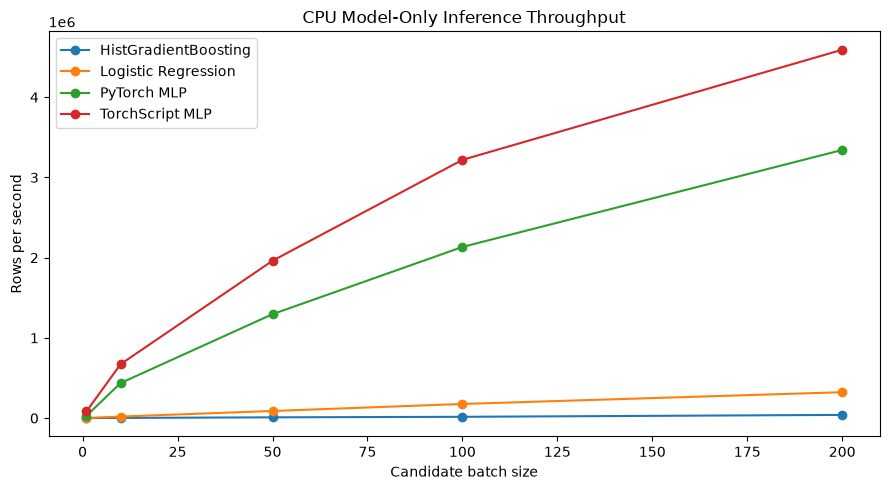

In [10]:
throughput_pivot = model_only_results.pivot(
    index="batch_size",
    columns="model",
    values="rows_per_second",
)

display(throughput_pivot.round(0))

plt.figure(figsize=(9, 5))

for model_name, group in model_only_results.groupby("model"):
    group = group.sort_values("batch_size")

    plt.plot(
        group["batch_size"],
        group["rows_per_second"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Candidate batch size")
plt.ylabel("Rows per second")
plt.title("CPU Model-Only Inference Throughput")
plt.legend()
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "model_only_throughput.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# Benchmark B — score + Top-K request path

This includes:

```text
candidate feature frame
      ↓
model preprocessing
      ↓
model scoring
      ↓
Top-10 selection
```

It still excludes candidate retrieval and dynamic feature construction.


In [11]:
TOP_K = 10

REQUEST_BATCH_SIZES = [10, 50, 100, 200]

REQUEST_REPEATS = {
    10: 200,
    50: 160,
    100: 120,
    200: 100,
}

print("Top-K:", TOP_K)
print("Request candidate sizes:", REQUEST_BATCH_SIZES)


Top-K: 10
Request candidate sizes: [10, 50, 100, 200]


## 9. Request-path functions

In [12]:
def topk_indices(scores, k=10):
    scores = np.asarray(scores)

    k = min(k, len(scores))

    if k <= 0:
        return np.array([], dtype=np.int64)

    if k == len(scores):
        return np.argsort(scores)[::-1]

    idx = np.argpartition(scores, -k)[-k:]

    return idx[np.argsort(scores[idx])[::-1]]

def request_logreg(frame):
    scores = logreg.predict_proba(
        frame[FEATURE_COLUMNS]
    )[:, 1]

    return topk_indices(scores, TOP_K)

def request_hgb(frame):
    X = hgb_imputer.transform(
        frame[FEATURE_COLUMNS]
    )

    scores = hgb.predict_proba(X)[:, 1]

    return topk_indices(scores, TOP_K)

def request_neural(frame, model):
    X = neural_imputer.transform(
        frame[FEATURE_COLUMNS]
    )

    X = neural_scaler.transform(X).astype(
        np.float32,
        copy=False,
    )

    tensor = torch.from_numpy(X)

    with torch.inference_mode():
        scores = torch.sigmoid(
            model(tensor)
        ).numpy()

    return topk_indices(scores, TOP_K)


## 10. End-to-end score + Top-K latency

In [13]:
REQUEST_MODELS = {
    "Logistic Regression": request_logreg,
    "HistGradientBoosting": request_hgb,
    "PyTorch MLP": lambda frame: request_neural(frame, neural_model),
    "TorchScript MLP": lambda frame: request_neural(frame, scripted_model),
}

request_rows = []

for batch_size in REQUEST_BATCH_SIZES:
    repeats = REQUEST_REPEATS[batch_size]

    for model_name, request_fn in REQUEST_MODELS.items():
        # Warmup
        for _ in range(10):
            idx = sample_indices(batch_size)
            request_fn(bench.iloc[idx])

        latencies = []

        for _ in range(repeats):
            idx = sample_indices(batch_size)
            frame = bench.iloc[idx]

            start = perf_counter()
            request_fn(frame)
            elapsed_ms = (perf_counter() - start) * 1000.0

            latencies.append(elapsed_ms)

        request_rows.append(
            summarize_latency(
                model_name,
                batch_size,
                latencies,
            )
        )

        print(
            f"Completed {model_name} | candidates={batch_size}"
        )

request_results = pd.DataFrame(request_rows)

display(request_results.round(4))


Completed Logistic Regression | candidates=10
Completed HistGradientBoosting | candidates=10
Completed PyTorch MLP | candidates=10
Completed TorchScript MLP | candidates=10
Completed Logistic Regression | candidates=50
Completed HistGradientBoosting | candidates=50
Completed PyTorch MLP | candidates=50
Completed TorchScript MLP | candidates=50
Completed Logistic Regression | candidates=100
Completed HistGradientBoosting | candidates=100
Completed PyTorch MLP | candidates=100
Completed TorchScript MLP | candidates=100
Completed Logistic Regression | candidates=200
Completed HistGradientBoosting | candidates=200
Completed PyTorch MLP | candidates=200
Completed TorchScript MLP | candidates=200


,model,batch_size,runs,mean_ms,p50_ms,p95_ms,p99_ms,rows_per_second
0,Logistic Regression,10,200,0.9409,0.6964,1.7829,5.1890,10628.0865
1,HistGradientBoosting,10,200,6.0451,5.1901,9.3596,10.9192,1654.2458
2,PyTorch MLP,10,200,0.6327,0.6317,0.6402,0.6586,15804.9202
3,TorchScript MLP,10,200,0.6070,0.5935,0.6513,0.7902,16475.8166
4,Logistic Regression,50,160,0.7208,0.7104,0.7590,0.8764,69362.9574
5,HistGradientBoosting,50,160,5.2730,4.9181,7.7366,9.6443,9482.2724
6,PyTorch MLP,50,160,0.6587,0.6580,0.6656,0.6708,75909.4536
7,TorchScript MLP,50,160,0.6240,0.6104,0.6496,0.6815,80131.6507
8,Logistic Regression,100,120,0.7128,0.7104,0.7318,0.7524,140300.8368
9,HistGradientBoosting,100,120,5.3650,4.9795,7.7870,13.4457,18639.2590


## 11. P50 / P95 / P99 at 200 candidates

,model,mean_ms,p50_ms,p95_ms,p99_ms,rows_per_second
0,TorchScript MLP,0.6945,0.6876,0.7231,0.7275,287967.9931
1,PyTorch MLP,0.7186,0.7211,0.7403,0.7500,278300.8863
2,Logistic Regression,0.7421,0.7361,0.7742,0.8275,269495.6160
3,HistGradientBoosting,5.2747,5.0860,6.6198,8.0158,37916.6538


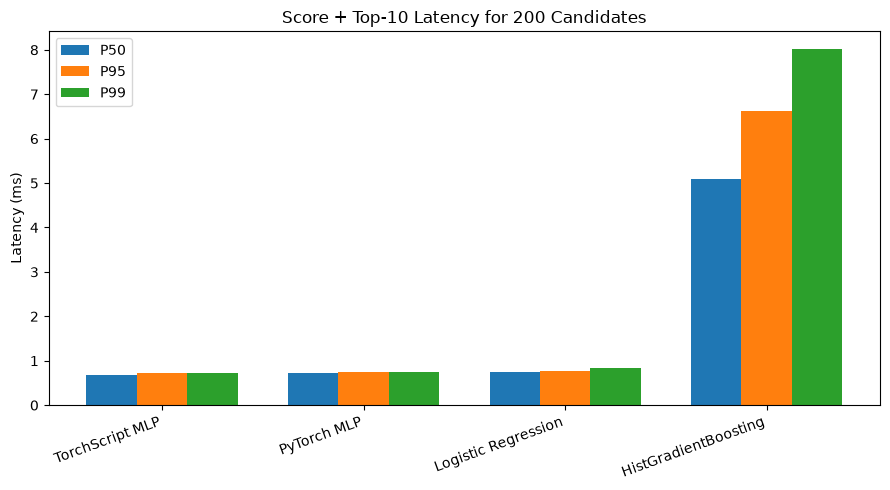

In [14]:
latency_200 = (
    request_results[
        request_results["batch_size"].eq(200)
    ]
    [
        [
            "model",
            "mean_ms",
            "p50_ms",
            "p95_ms",
            "p99_ms",
            "rows_per_second",
        ]
    ]
    .sort_values("p95_ms")
    .reset_index(drop=True)
)

display(latency_200.round(4))

plt.figure(figsize=(9, 5))

plot_200 = latency_200.set_index("model")
x = np.arange(len(plot_200))
width = 0.25

plt.bar(x - width, plot_200["p50_ms"], width, label="P50")
plt.bar(x, plot_200["p95_ms"], width, label="P95")
plt.bar(x + width, plot_200["p99_ms"], width, label="P99")

plt.xticks(
    x,
    plot_200.index,
    rotation=20,
    ha="right",
)

plt.ylabel("Latency (ms)")
plt.title("Score + Top-10 Latency for 200 Candidates")
plt.legend()
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "latency_200_candidates.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


## 12. Top-K sorting overhead alone

In [15]:
SORT_REPEATS = 1000
sorting_rows = []

for batch_size in REQUEST_BATCH_SIZES:
    scores = rng.random(
        batch_size,
        dtype=np.float32,
    )

    latencies = []

    for _ in range(SORT_REPEATS):
        start = perf_counter()

        topk_indices(scores, TOP_K)

        latencies.append(
            (perf_counter() - start) * 1000.0
        )

    sorting_rows.append(
        summarize_latency(
            "Top-K only",
            batch_size,
            latencies,
        )
    )

sorting_results = pd.DataFrame(sorting_rows)

display(sorting_results.round(6))


,model,batch_size,runs,mean_ms,p50_ms,p95_ms,p99_ms,rows_per_second
0,Top-K only,10,1000,0.001519,0.000917,0.002291,0.008963,6.581820e+06
1,Top-K only,50,1000,0.002064,0.002000,0.002084,0.002835,2.422436e+07
2,Top-K only,100,1000,0.002104,0.002084,0.002167,0.002208,4.752150e+07
3,Top-K only,200,1000,0.002312,0.002292,0.002375,0.003000,8.649212e+07


## 13. Final ranker latency summary

In [16]:
hgb_200 = latency_200[
    latency_200["model"].eq(
        "HistGradientBoosting"
    )
]

if hgb_200.empty:
    raise ValueError(
        "Missing HGB 200-candidate benchmark."
    )

hgb_p50_ms = float(
    hgb_200.iloc[0]["p50_ms"]
)

hgb_p95_ms = float(
    hgb_200.iloc[0]["p95_ms"]
)

hgb_p99_ms = float(
    hgb_200.iloc[0]["p99_ms"]
)

print("Selected quality ranker: HistGradientBoosting")
print("HGB 200-candidate P50:", round(hgb_p50_ms, 4), "ms")
print("HGB 200-candidate P95:", round(hgb_p95_ms, 4), "ms")
print("HGB 200-candidate P99:", round(hgb_p99_ms, 4), "ms")


Selected quality ranker: HistGradientBoosting
HGB 200-candidate P50: 5.086 ms
HGB 200-candidate P95: 6.6198 ms
HGB 200-candidate P99: 8.0158 ms


## 14. Save Notebook 07 results

In [17]:
model_only_results.to_csv(
    RESULTS_DIR / "model_only_inference_benchmark.csv",
    index=False,
)

request_results.to_csv(
    RESULTS_DIR / "request_path_inference_benchmark.csv",
    index=False,
)

latency_200.to_csv(
    RESULTS_DIR / "latency_200_candidates.csv",
    index=False,
)

sorting_results.to_csv(
    RESULTS_DIR / "topk_sorting_benchmark.csv",
    index=False,
)

metadata = {
    "device": str(DEVICE),
    "torch_version": torch.__version__,
    "torch_threads": int(torch.get_num_threads()),
    "benchmark_rows": int(len(bench)),
    "benchmark_users": int(bench["user_id"].nunique()),
    "feature_count": int(len(FEATURE_COLUMNS)),
    "candidate_batch_sizes": BATCH_SIZES,
    "request_candidate_sizes": REQUEST_BATCH_SIZES,
    "top_k": TOP_K,
    "selected_quality_ranker": "HistGradientBoosting",
    "hgb_200_candidate_p50_ms": hgb_p50_ms,
    "hgb_200_candidate_p95_ms": hgb_p95_ms,
    "hgb_200_candidate_p99_ms": hgb_p99_ms,
    "artifacts": {
        "logreg": str(LOGREG_PATH),
        "hgb": str(HGB_PATH),
        "neural": str(NEURAL_MODEL_PATH),
        "torchscript": str(TORCHSCRIPT_PATH),
    },
}

with open(
    ARTIFACT_DIR / "inference_benchmark_metadata.json",
    "w",
) as f:
    json.dump(metadata, f, indent=2)

print("Saved results to:")
print(RESULTS_DIR)

print("\nSaved metadata:")
print(
    ARTIFACT_DIR / "inference_benchmark_metadata.json"
)


Saved results to:
/Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/results/07_twitch_inference_benchmark

Saved metadata:
/Users/noopur/Desktop/resume_projects/Distributed ML Inference & Ranking/artifacts/twitch/inference_benchmark_metadata.json


# Notebook 07 complete — notebook phase finished

The seven-notebook sequence is now complete:

```text
01 EDA
02 Ranking dataset preparation
03 Classical rankers
04 Neural ranker
05 Candidate generation v2
06 Ranking evaluation
07 Inference benchmark
```

## Next phase — actual inference system

Stop adding notebooks.

```text
src/
├── retrieval/
│   └── candidate_generator.py
├── features/
│   └── dynamic_features.py
├── ranking/
│   └── ranker.py
└── inference/
    └── engine.py
```

First implement the exact 36-feature dynamic builder:

```text
user
 ↓
candidate generator
 ↓
200 candidates
 ↓
dynamic 36-feature builder
 ↓
HGB
 ↓
Top-10
```

Then add:

```text
FastAPI
 ↓
multiple inference replicas
 ↓
Redis
 ↓
Locust load testing
 ↓
Docker
```
